In [ ]:
# Install libraries yang diperlukan
!pip install -q scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
plt.style.use('default')
sns.set_palette("husl")

print("✅ Semua libraries berhasil diimport!")
print("📅 Project: KNN Air Quality Prediction")
print("👤 Developer: Ishigami7")
print("🕐 Started at: 2025-06-30 12:15:04 UTC")

✅ Semua libraries berhasil diimport!
📅 Project: KNN Air Quality Prediction
👤 Developer: Ishigami7
🕐 Started at: 2025-06-30 12:15:04 UTC


In [ ]:
from google.colab import files
import io

print("📁 Silakan upload file olah_data_stasiun.csv")
print("Klik 'Choose Files' dan pilih file CSV Anda...")

uploaded = files.upload()

# Load dataset
for filename in uploaded.keys():
    if filename.endswith('.csv'):
        df = pd.read_csv(io.BytesIO(uploaded[filename]))
        print(f"✅ Dataset {filename} berhasil diupload!")
        print(f"📊 Shape: {df.shape}")
        print(f"🗂️ Columns: {list(df.columns)}")
        break

# Quick preview
print("\n🔍 Preview data (5 baris pertama):")
df.head()

📁 Silakan upload file olah_data_stasiun.csv
Klik 'Choose Files' dan pilih file CSV Anda...


Saving olah_data_stasiun.csv to olah_data_stasiun.csv
✅ Dataset olah_data_stasiun.csv berhasil diupload!
📊 Shape: (2914, 7)
🗂️ Columns: ['waktu', 'pm10', 'pm2.5', 'so2', 'co', 'o3', 'no2']

🔍 Preview data (5 baris pertama):


,waktu,pm10,pm2.5,so2,co,o3,no2
0,11/1/2024,62,7.0,44,612.0,40.0,115.0
1,11/1/2024,79,6.0,45,585.0,43.0,131.0
2,11/1/2024,67,7.0,46,566.0,50.0,143.0
3,11/1/2024,69,6.0,45,541.0,55.0,157.0
4,11/1/2024,63,6.0,45,503.0,66.0,168.0


In [ ]:
print("🔍 EKSPLORASI DATA LENGKAP")
print("=" * 60)

# Basic info
print(f"📊 Dataset Shape: {df.shape}")
print(f"📋 Columns: {list(df.columns)}")
print(f"🧮 Data Types:")
print(df.dtypes)

print(f"\n❓ Missing Values:")
missing_summary = df.isnull().sum()
print(missing_summary)
total_missing = missing_summary.sum()
print(f"📊 Total Missing Values: {total_missing}")

print(f"\n📈 Basic Statistics:")
df.describe()

🔍 EKSPLORASI DATA LENGKAP
📊 Dataset Shape: (2914, 7)
📋 Columns: ['waktu', 'pm10', 'pm2.5', 'so2', 'co', 'o3', 'no2']
🧮 Data Types:
waktu     object
pm10       int64
pm2.5    float64
so2        int64
co       float64
o3       float64
no2      float64
dtype: object

❓ Missing Values:
waktu       0
pm10        0
pm2.5     126
so2         0
co          5
o3       1943
no2      1104
dtype: int64
📊 Total Missing Values: 3178

📈 Basic Statistics:


,pm10,pm2.5,so2,co,o3,no2
count,2914.000000,2788.000000,2914.000000,2909.000000,971.000000,1810.000000
mean,34.163006,28.538020,30.164722,468.895153,21.971164,103.574586
std,26.867512,99.817057,10.336543,447.645749,18.018467,49.596495
min,1.000000,1.000000,16.000000,1.000000,7.000000,25.000000
25%,16.000000,1.000000,22.000000,146.000000,10.000000,44.000000
50%,27.000000,2.000000,26.000000,318.000000,12.000000,132.000000
75%,42.000000,5.000000,39.000000,650.000000,34.000000,143.000000
max,237.000000,700.000000,62.000000,3675.000000,110.000000,200.000000


In [ ]:
print("🧹 DATA PREPROCESSING")
print("=" * 60)

# Copy dataset untuk preprocessing
df_clean = df.copy()

# Drop kolom waktu jika ada
if 'waktu' in df_clean.columns:
    df_clean = df_clean.drop('waktu', axis=1)
    print("✅ Kolom 'waktu' telah dihapus")

print("📊 Data sebelum cleaning:")
print(f"Shape: {df_clean.shape}")
print("Missing values:")
print(df_clean.isnull().sum())

# Handle missing values dengan median imputation
print("\n🔧 Mengatasi missing values dengan median imputation...")
imputer = SimpleImputer(strategy='median')
df_clean_filled = pd.DataFrame(
    imputer.fit_transform(df_clean),
    columns=df_clean.columns
)

print("\n✅ Data setelah cleaning:")
print(f"Shape: {df_clean_filled.shape}")
print("Missing values:")
print(df_clean_filled.isnull().sum())

# Pastikan tidak ada nilai negatif
for col in df_clean_filled.columns:
    negative_count = (df_clean_filled[col] < 0).sum()
    if negative_count > 0:
        print(f"⚠️ Ditemukan {negative_count} nilai negatif di kolom {col}")
        df_clean_filled[col] = np.maximum(df_clean_filled[col], 0)

print("\n📊 Final statistics after cleaning:")
df_clean_filled.describe()

🧹 DATA PREPROCESSING
✅ Kolom 'waktu' telah dihapus
📊 Data sebelum cleaning:
Shape: (2914, 6)
Missing values:
pm10        0
pm2.5     126
so2         0
co          5
o3       1943
no2      1104
dtype: int64

🔧 Mengatasi missing values dengan median imputation...

✅ Data setelah cleaning:
Shape: (2914, 6)
Missing values:
pm10     0
pm2.5    0
so2      0
co       0
o3       0
no2      0
dtype: int64

📊 Final statistics after cleaning:


,pm10,pm2.5,so2,co,o3,no2
count,2914.000000,2914.000000,2914.000000,2914.000000,2914.000000,2914.000000
mean,34.163006,27.390528,30.164722,468.636239,15.322581,114.343857
std,26.867512,97.783576,10.336543,447.305018,11.410885,41.446053
min,1.000000,1.000000,16.000000,1.000000,7.000000,25.000000
25%,16.000000,1.000000,22.000000,146.250000,12.000000,100.000000
50%,27.000000,2.000000,26.000000,318.000000,12.000000,132.000000
75%,42.000000,5.000000,39.000000,648.500000,12.000000,137.000000
max,237.000000,700.000000,62.000000,3675.000000,110.000000,200.000000


In [ ]:
print("🎯 FEATURE ENGINEERING - MEMBUAT LABEL TARGET")
print("=" * 60)

def calculate_air_quality_category(row):
    """
    Menentukan kategori kualitas udara berdasarkan standar ISPU
    Menggunakan worst case scenario dari semua parameter
    """
    pm10 = row['pm10']
    pm25 = row['pm2.5']
    so2 = row['so2']
    co = row['co']
    o3 = row['o3']
    no2 = row['no2']

    scores = []

    # PM10 scoring (μg/m³)
    if pm10 <= 50:
        scores.append(1)  # Baik
    elif pm10 <= 150:
        scores.append(2)  # Sedang
    else:
        scores.append(3)  # Buruk

    # PM2.5 scoring (μg/m³)
    if pm25 <= 15:
        scores.append(1)
    elif pm25 <= 65:
        scores.append(2)
    else:
        scores.append(3)

    # SO2 scoring (μg/m³)
    if so2 <= 52:
        scores.append(1)
    elif so2 <= 180:
        scores.append(2)
    else:
        scores.append(3)

    # CO scoring (μg/m³)
    if co <= 4000:
        scores.append(1)
    elif co <= 8000:
        scores.append(2)
    else:
        scores.append(3)

    # O3 scoring (μg/m³)
    if o3 <= 120:
        scores.append(1)
    elif o3 <= 180:
        scores.append(2)
    else:
        scores.append(3)

    # NO2 scoring (μg/m³)
    if no2 <= 80:
        scores.append(1)
    elif no2 <= 200:
        scores.append(2)
    else:
        scores.append(3)

    # Ambil score tertinggi (worst case)
    max_score = max(scores)

    if max_score == 1:
        return 'Baik'
    elif max_score == 2:
        return 'Sedang'
    else:
        return 'Buruk'

# Terapkan fungsi untuk membuat target variable
print("🔄 Menghitung kategori kualitas udara...")
df_clean_filled['kualitas_udara'] = df_clean_filled.apply(calculate_air_quality_category, axis=1)

print("\n📊 Distribusi Kualitas Udara:")
distribution = df_clean_filled['kualitas_udara'].value_counts()
print(distribution)

print("\n📈 Persentase distribusi:")
percentage = df_clean_filled['kualitas_udara'].value_counts(normalize=True) * 100
for category, pct in percentage.items():
    emoji = "🟢" if category == "Baik" else "🟡" if category == "Sedang" else "🔴"
    print(f"{emoji} {category}: {pct:.2f}%")

print("\n✅ Feature engineering selesai!")

🎯 FEATURE ENGINEERING - MEMBUAT LABEL TARGET
🔄 Menghitung kategori kualitas udara...

📊 Distribusi Kualitas Udara:
kualitas_udara
Sedang    2210
Baik       449
Buruk      255
Name: count, dtype: int64

📈 Persentase distribusi:
🟡 Sedang: 75.84%
🟢 Baik: 15.41%
🔴 Buruk: 8.75%

✅ Feature engineering selesai!


📊 VISUALISASI DATA KUALITAS UDARA
👤 Analyst: Ishigami7
📅 2025-06-30 12:26:00 UTC
🎨 Membuat visualisasi distribusi parameter...


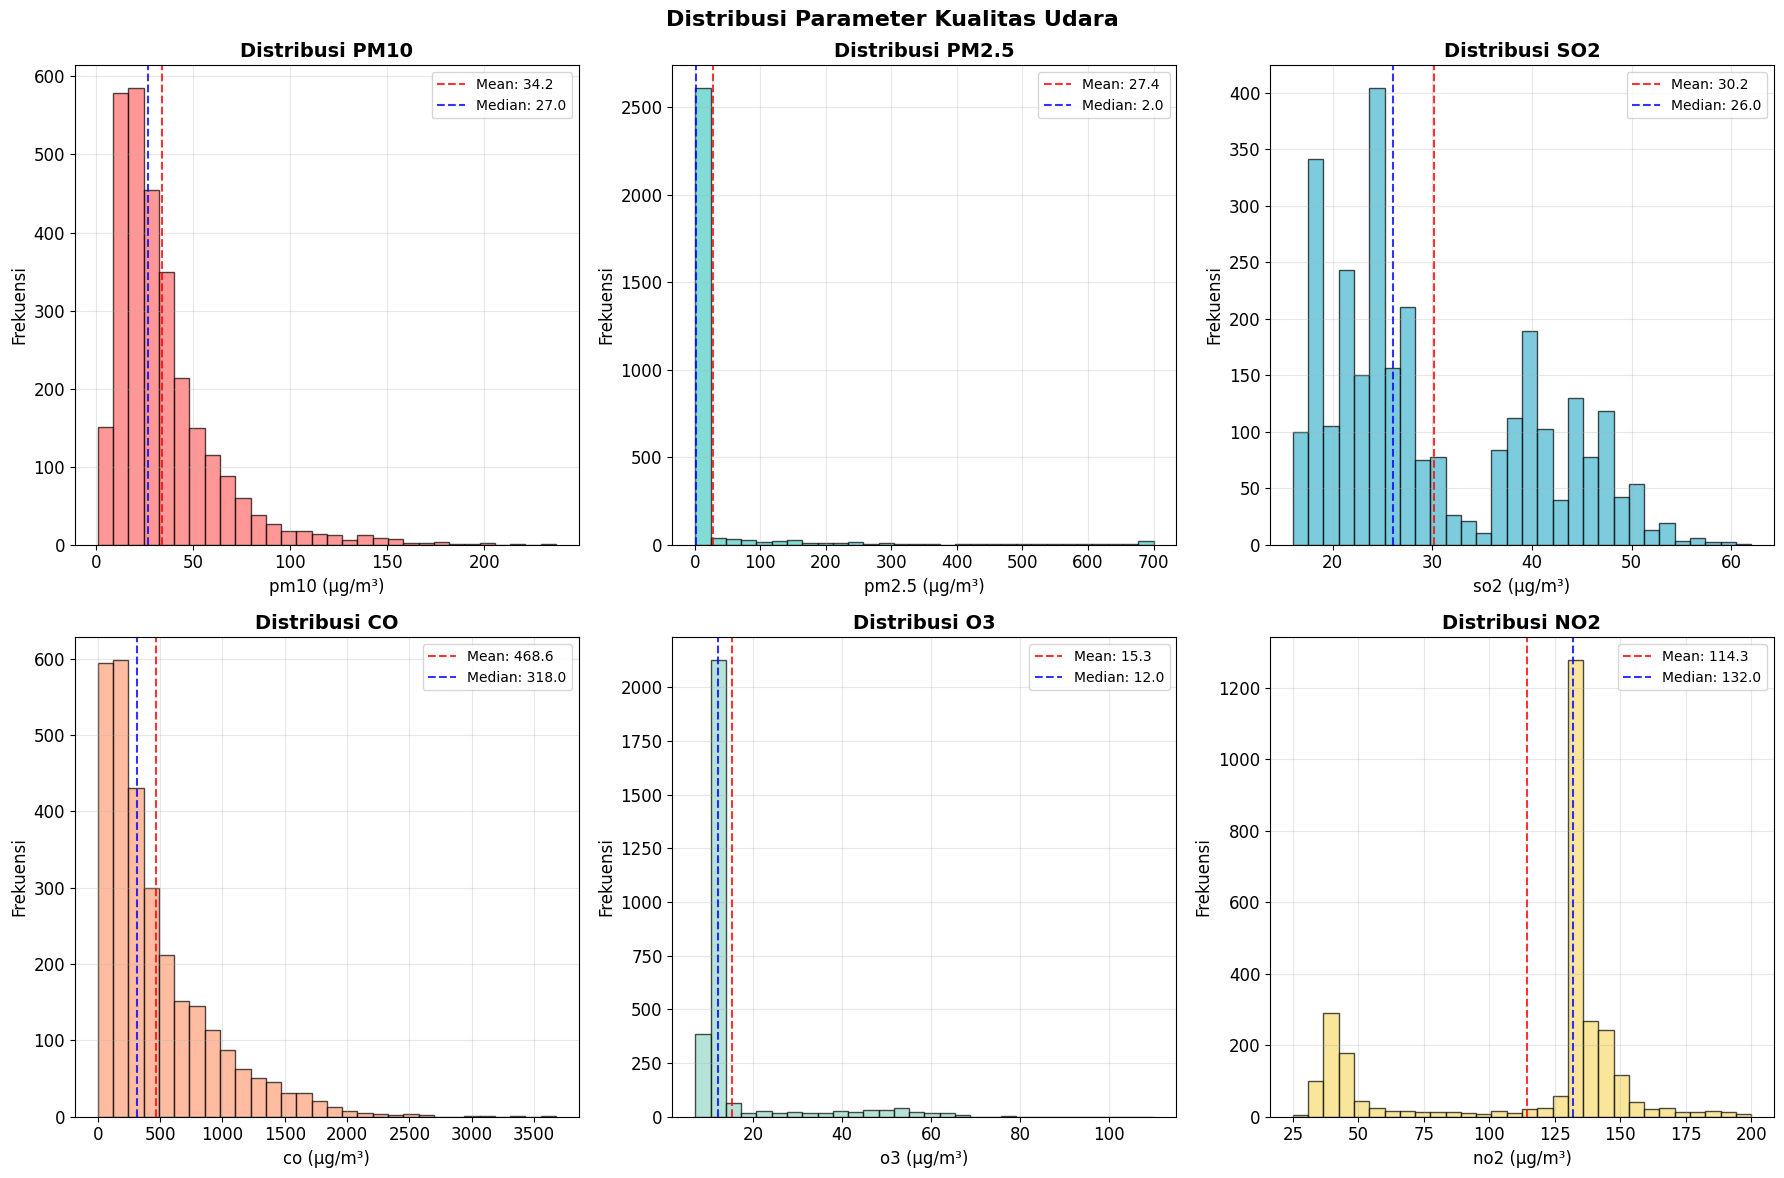


🎯 Visualisasi distribusi kategori kualitas udara...


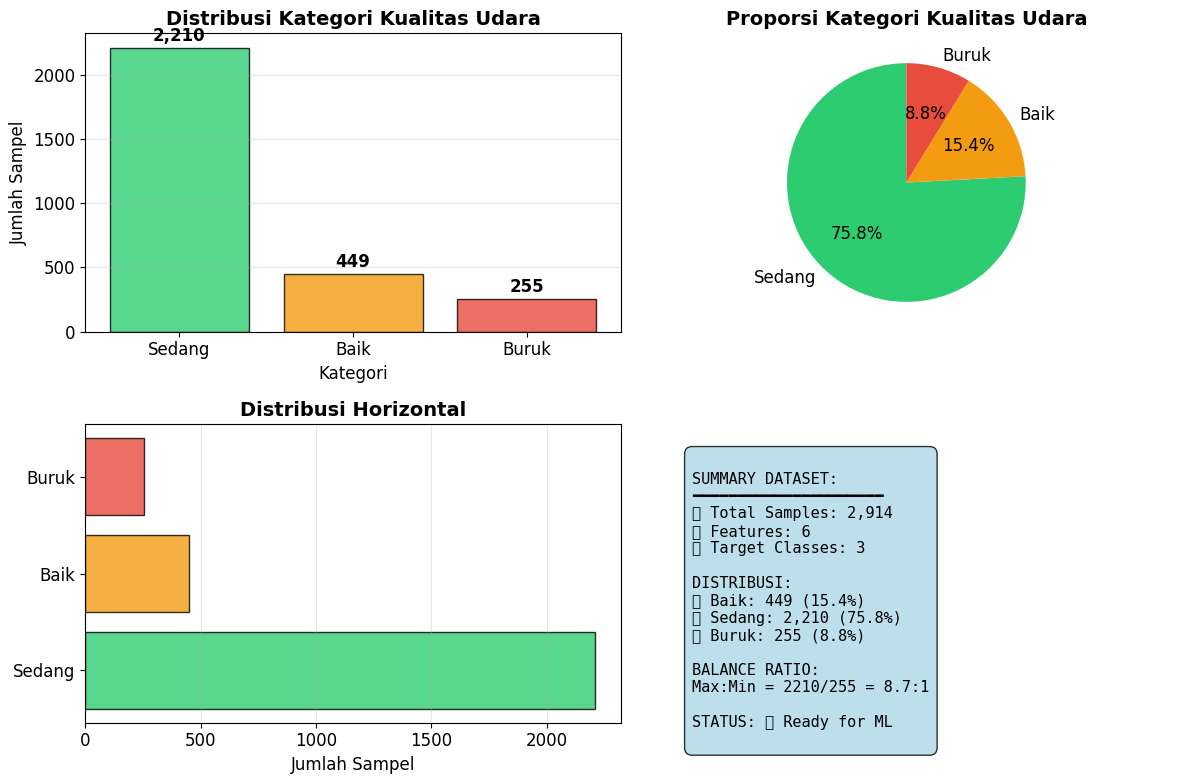

✅ Visualisasi distribusi selesai!


In [ ]:
print("📊 VISUALISASI DATA KUALITAS UDARA")
print("=" * 60)
print(f"👤 Analyst: Ishigami7")
print(f"📅 {2025}-06-30 12:26:00 UTC")

# Setup untuk visualisasi
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 12

# 1. Distribusi Parameter Polutan
print("🎨 Membuat visualisasi distribusi parameter...")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribusi Parameter Kualitas Udara', fontsize=16, fontweight='bold')

parameters = ['pm10', 'pm2.5', 'so2', 'co', 'o3', 'no2']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']

for i, (param, color) in enumerate(zip(parameters, colors)):
    row = i // 3
    col = i % 3

    axes[row, col].hist(df_clean_filled[param], bins=30, color=color, alpha=0.7, edgecolor='black')
    axes[row, col].set_title(f'Distribusi {param.upper()}', fontweight='bold', fontsize=14)
    axes[row, col].set_xlabel(f'{param} (μg/m³)')
    axes[row, col].set_ylabel('Frekuensi')
    axes[row, col].grid(True, alpha=0.3)

    # Tambahkan statistik
    mean_val = df_clean_filled[param].mean()
    median_val = df_clean_filled[param].median()
    axes[row, col].axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.1f}')
    axes[row, col].axvline(median_val, color='blue', linestyle='--', alpha=0.8, label=f'Median: {median_val:.1f}')
    axes[row, col].legend(fontsize=10)

plt.tight_layout()
plt.show()

# 2. Visualisasi Target Variable
print("\n🎯 Visualisasi distribusi kategori kualitas udara...")
plt.figure(figsize=(12, 8))

# Subplot 1: Bar Chart
plt.subplot(2, 2, 1)
colors_target = ['#2ECC71', '#F39C12', '#E74C3C']  # Green, Orange, Red
bars = plt.bar(distribution.index, distribution.values, color=colors_target, alpha=0.8, edgecolor='black')
plt.title('Distribusi Kategori Kualitas Udara', fontsize=14, fontweight='bold')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Sampel')
plt.grid(axis='y', alpha=0.3)

# Tambahkan label pada bar
for bar, value in zip(bars, distribution.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{value:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Subplot 2: Pie Chart
plt.subplot(2, 2, 2)
wedges, texts, autotexts = plt.pie(distribution.values, labels=distribution.index,
                                  colors=colors_target, autopct='%1.1f%%', startangle=90)
plt.title('Proporsi Kategori Kualitas Udara', fontsize=14, fontweight='bold')

# Subplot 3: Horizontal Bar
plt.subplot(2, 2, 3)
y_pos = range(len(distribution))
plt.barh(y_pos, distribution.values, color=colors_target, alpha=0.8, edgecolor='black')
plt.yticks(y_pos, distribution.index)
plt.xlabel('Jumlah Sampel')
plt.title('Distribusi Horizontal', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Subplot 4: Statistics Summary
plt.subplot(2, 2, 4)
plt.axis('off')
stats_text = f"""
SUMMARY DATASET:
━━━━━━━━━━━━━━━━━━━━━
📊 Total Samples: {len(df_clean_filled):,}
📋 Features: {len(parameters)}
🎯 Target Classes: {len(distribution)}

DISTRIBUSI:
🟢 Baik: {distribution.get('Baik', 0):,} ({percentage.get('Baik', 0):.1f}%)
🟡 Sedang: {distribution.get('Sedang', 0):,} ({percentage.get('Sedang', 0):.1f}%)
🔴 Buruk: {distribution.get('Buruk', 0):,} ({percentage.get('Buruk', 0):.1f}%)

BALANCE RATIO:
Max:Min = {distribution.max()}/{distribution.min()} = {distribution.max()/distribution.min():.1f}:1

STATUS: ✅ Ready for ML
"""
plt.text(0.1, 0.9, stats_text, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))

plt.tight_layout()
plt.show()

print("✅ Visualisasi distribusi selesai!")

🔍 CORRELATION MATRIX & ADVANCED ANALYSIS
👤 Analyst: Ishigami7
📅 2025-06-30 12:29:30 UTC
📊 Membuat correlation matrix antar parameter...


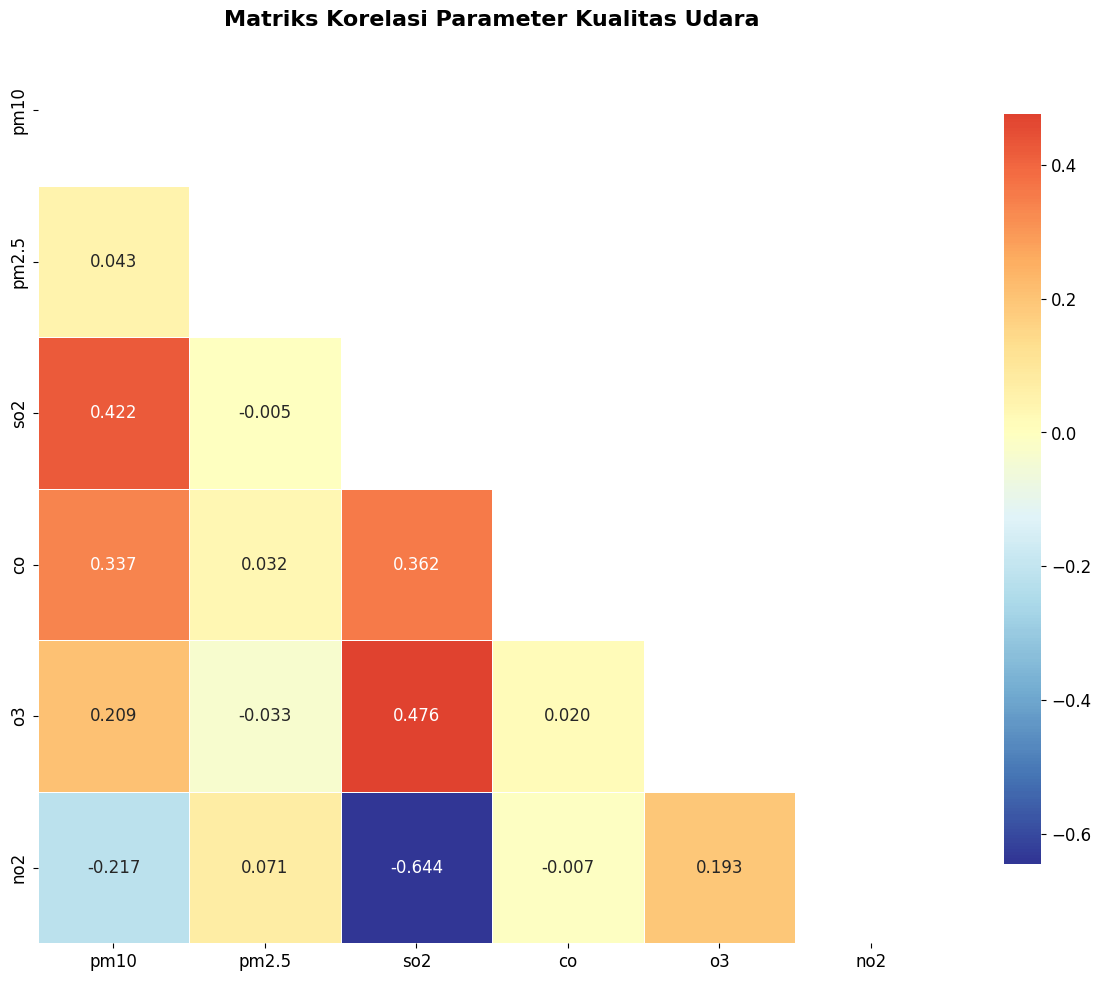


🔍 ANALISIS KORELASI:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔗 Top 5 Korelasi Tertinggi:
🟡 1. SO2 ↔ NO2: -0.644 (Kuat Negatif)
🟢 2. SO2 ↔ O3: 0.476 (Sedang Positif)
🟢 3. PM10 ↔ SO2: 0.422 (Sedang Positif)
🟢 4. SO2 ↔ CO: 0.362 (Lemah Positif)
🟢 5. PM10 ↔ CO: 0.337 (Lemah Positif)

📦 Membuat boxplot distribusi parameter per kategori...


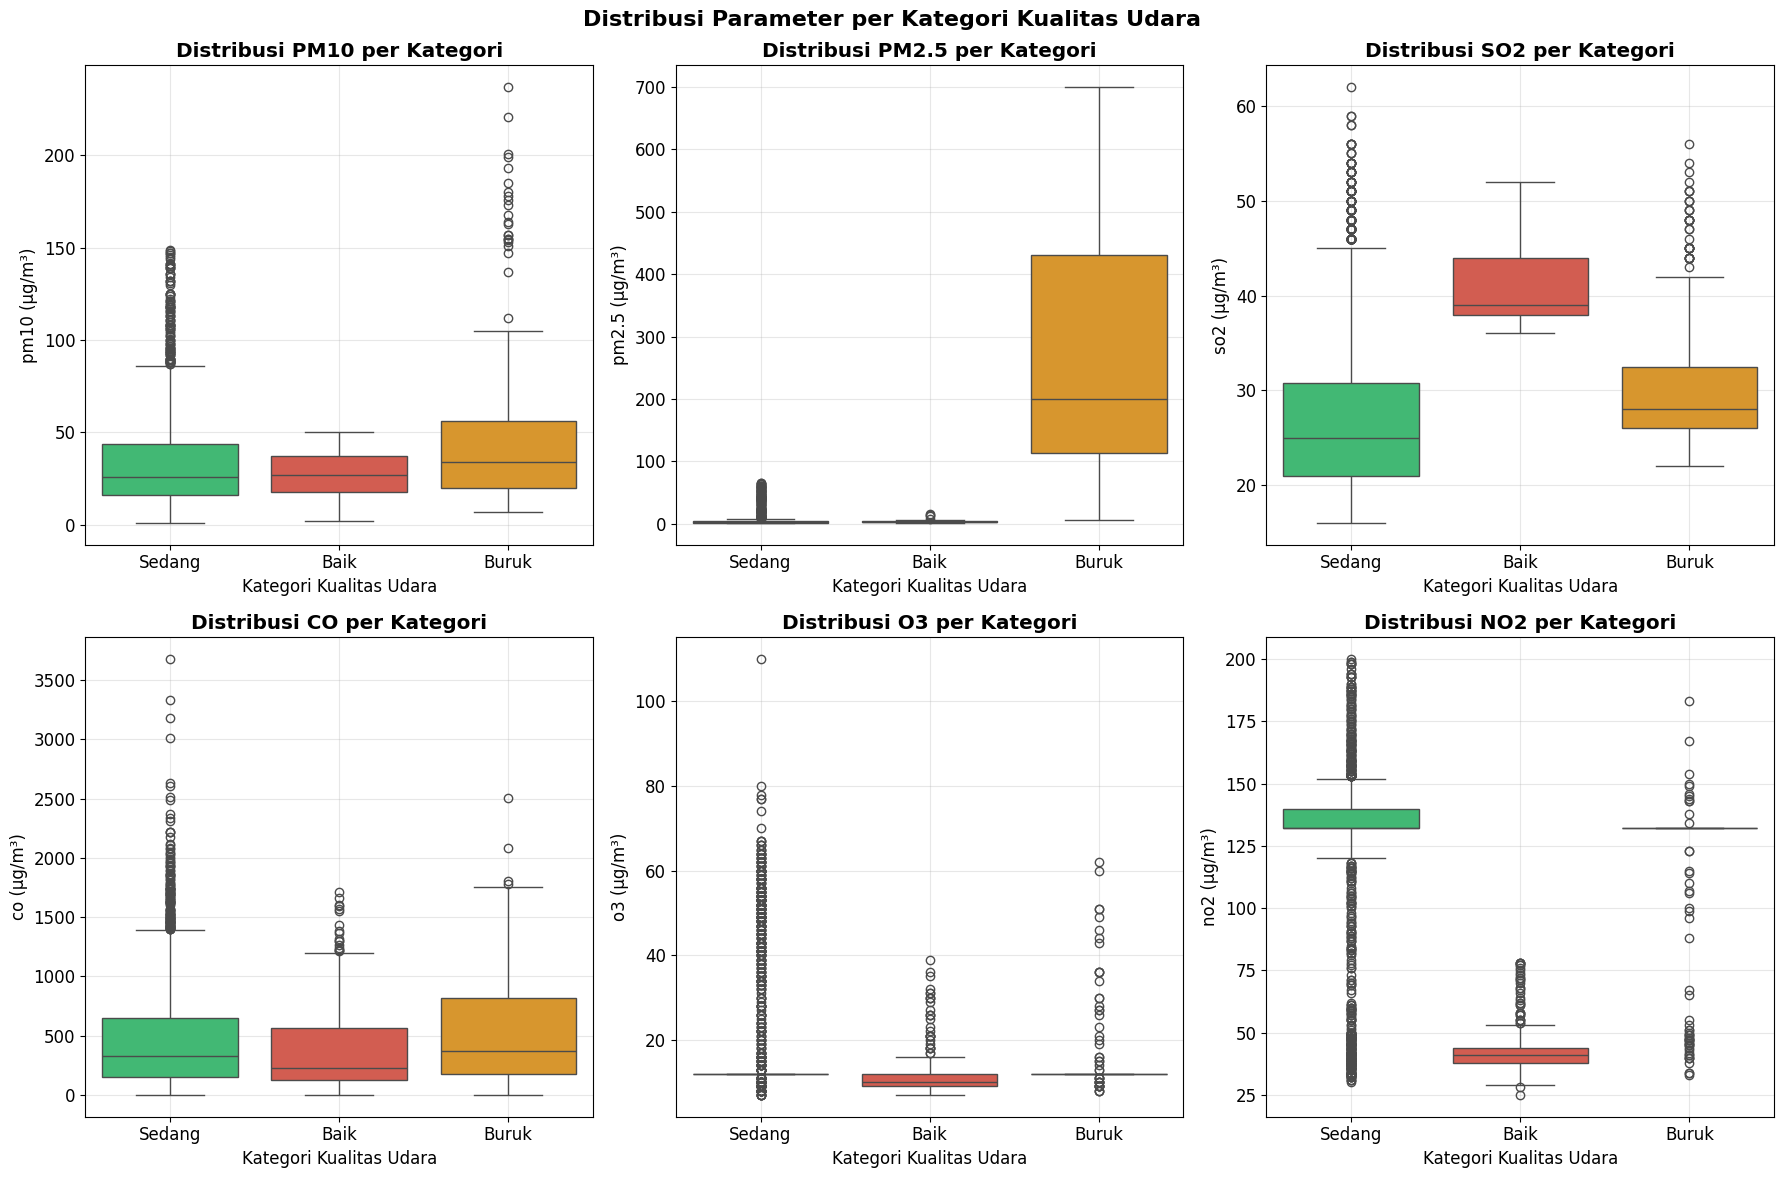


📊 ANALISIS STATISTIK PER KATEGORI:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🟢 KATEGORI BAIK (449 samples):
┌─────────┬─────────┬─────────┬─────────┬─────────┐
│Parameter│   Min   │  Mean   │ Median  │   Max   │
├─────────┼─────────┼─────────┼─────────┼─────────┤
│pm10     │     2.0 │    27.5 │    27.0 │    50.0 │
│pm2.5    │     1.0 │     3.0 │     3.0 │    15.0 │
│so2      │    36.0 │    41.0 │    39.0 │    52.0 │
│co       │     3.0 │   392.9 │   228.0 │  1715.0 │
│o3       │     7.0 │    11.2 │    10.0 │    39.0 │
│no2      │    25.0 │    42.6 │    41.0 │    78.0 │
└─────────┴─────────┴─────────┴─────────┴─────────┘

🟡 KATEGORI SEDANG (2210 samples):
┌─────────┬─────────┬─────────┬─────────┬─────────┐
│Parameter│   Min   │  Mean   │ Median  │   Max   │
├─────────┼─────────┼─────────┼─────────┼─────────┤
│pm10     │     1.0 │    34.0 │    26.0 │   149.0 │
│pm2.5    │     1.0 │     4.1 │     2.0 │    65.0 │
│so2      │    16.0 │    27.9 │    25.0 │    62.0 │
│co       │  

In [ ]:
print("🔍 CORRELATION MATRIX & ADVANCED ANALYSIS")
print("=" * 60)
print(f"👤 Analyst: Ishigami7")
print(f"📅 2025-06-30 12:29:30 UTC")

# 1. Correlation Matrix
print("📊 Membuat correlation matrix antar parameter...")
plt.figure(figsize=(12, 10))

# Hitung korelasi
correlation_matrix = df_clean_filled[parameters].corr()

# Create heatmap
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='RdYlBu_r',
            center=0,
            square=True,
            fmt='.3f',
            cbar_kws={'shrink': 0.8},
            mask=mask,
            linewidths=0.5)

plt.title('Matriks Korelasi Parameter Kualitas Udara', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Analisis korelasi
print("\n🔍 ANALISIS KORELASI:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

# Cari korelasi tertinggi
correlations = []
for i in range(len(parameters)):
    for j in range(i+1, len(parameters)):
        param1, param2 = parameters[i], parameters[j]
        corr_value = correlation_matrix.loc[param1, param2]
        correlations.append((param1, param2, corr_value))

# Sort berdasarkan nilai absolut korelasi
correlations.sort(key=lambda x: abs(x[2]), reverse=True)

print("🔗 Top 5 Korelasi Tertinggi:")
for i, (param1, param2, corr) in enumerate(correlations[:5], 1):
    strength = "Sangat Kuat" if abs(corr) > 0.8 else "Kuat" if abs(corr) > 0.6 else "Sedang" if abs(corr) > 0.4 else "Lemah"
    direction = "Positif" if corr > 0 else "Negatif"
    emoji = "🔴" if abs(corr) > 0.7 else "🟡" if abs(corr) > 0.5 else "🟢"
    print(f"{emoji} {i}. {param1.upper()} ↔ {param2.upper()}: {corr:.3f} ({strength} {direction})")

# 2. Boxplot by Category
print(f"\n📦 Membuat boxplot distribusi parameter per kategori...")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribusi Parameter per Kategori Kualitas Udara', fontsize=16, fontweight='bold')

for i, param in enumerate(parameters):
    row = i // 3
    col = i % 3

    sns.boxplot(data=df_clean_filled, x='kualitas_udara', y=param,
                ax=axes[row, col], palette=['#2ECC71', '#E74C3C', '#F39C12'])

    axes[row, col].set_title(f'Distribusi {param.upper()} per Kategori', fontweight='bold')
    axes[row, col].set_xlabel('Kategori Kualitas Udara')
    axes[row, col].set_ylabel(f'{param} (μg/m³)')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Statistical Analysis per Category
print(f"\n📊 ANALISIS STATISTIK PER KATEGORI:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

for category in ['Baik', 'Sedang', 'Buruk']:
    if category in df_clean_filled['kualitas_udara'].values:
        category_data = df_clean_filled[df_clean_filled['kualitas_udara'] == category]
        emoji = "🟢" if category == "Baik" else "🟡" if category == "Sedang" else "🔴"

        print(f"\n{emoji} KATEGORI {category.upper()} ({len(category_data)} samples):")
        print("┌─────────┬─────────┬─────────┬─────────┬─────────┐")
        print("│Parameter│   Min   │  Mean   │ Median  │   Max   │")
        print("├─────────┼─────────┼─────────┼─────────┼─────────┤")

        for param in parameters:
            min_val = category_data[param].min()
            mean_val = category_data[param].mean()
            median_val = category_data[param].median()
            max_val = category_data[param].max()
            print(f"│{param:<9}│{min_val:>8.1f} │{mean_val:>8.1f} │{median_val:>8.1f} │{max_val:>8.1f} │")

        print("└─────────┴─────────┴─────────┴─────────┴─────────┘")

# 4. Feature Separation Analysis
print(f"\n🎯 ANALISIS SEPARABILITAS FEATURES:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

separation_scores = {}
for param in parameters:
    baik_mean = df_clean_filled[df_clean_filled['kualitas_udara'] == 'Baik'][param].mean()
    sedang_mean = df_clean_filled[df_clean_filled['kualitas_udara'] == 'Sedang'][param].mean()
    buruk_mean = df_clean_filled[df_clean_filled['kualitas_udara'] == 'Buruk'][param].mean()

    # Hitung separation score (range antar kategori)
    separation = max(baik_mean, sedang_mean, buruk_mean) - min(baik_mean, sedang_mean, buruk_mean)
    separation_scores[param] = separation

# Sort berdasarkan separation score
sorted_features = sorted(separation_scores.items(), key=lambda x: x[1], reverse=True)

print("🏆 Ranking Feature Separability (untuk KNN):")
for i, (param, score) in enumerate(sorted_features, 1):
    stars = "⭐⭐⭐" if i <= 2 else "⭐⭐" if i <= 4 else "⭐"
    print(f"{i}. {param.upper():<8}: {score:>8.1f} μg/m³ {stars}")

print(f"\n💡 INSIGHTS UNTUK MODEL KNN:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"✅ Dataset siap untuk KNN dengan {len(df_clean_filled):,} samples")
print(f"✅ Feature dengan separability terbaik: {sorted_features[0][0].upper()}")
print(f"✅ Feature dengan separability terendah: {sorted_features[-1][0].upper()}")
print(f"✅ Correlation tertinggi: {correlations[0][0].upper()} ↔ {correlations[0][1].upper()} ({correlations[0][2]:.3f})")
print(f"✅ Balance ratio: {distribution.max()/distribution.min():.1f}:1 (acceptable untuk KNN)")

print(f"\n🚀 Siap untuk preprocessing dan training model KNN!")

⚙️ DATA PREPARATION & FEATURE SCALING
👤 Analyst: Ishigami7
📅 2025-06-30 12:30:58 UTC
🎯 Objective: Mempersiapkan data untuk training KNN model

🔄 MEMISAHKAN FEATURES DAN TARGET:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ Features (X):
   ├── Shape: (2914, 6)
   ├── Columns: ['pm10', 'pm2.5', 'so2', 'co', 'o3', 'no2']
   └── Data Type: Numerical (continuous)

✅ Target (y):
   ├── Shape: (2914,)
   ├── Classes: ['Sedang', 'Baik', 'Buruk']
   ├── Distribution: {'Sedang': np.int64(2210), 'Baik': np.int64(449), 'Buruk': np.int64(255)}
   └── Data Type: Categorical (3 classes)

📊 TRAIN-TEST SPLIT:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ Training Set:
   ├── X_train: (2331, 6)
   ├── y_train: (2331,)
   └── Proportion: 80.0% of total data

✅ Test Set:
   ├── X_test: (583, 6)
   ├── y_test: (583,)
   └── Proportion: 20.0% of total data

📈 DISTRIBUSI KELAS SETELAH SPLIT:
Training Set Distribution:
   🟢 Baik: 359 (15.4%)
   🟡 Sedang: 1,768 (75.8%)
   🔴 Buruk: 204 (8.8%)
Test Se

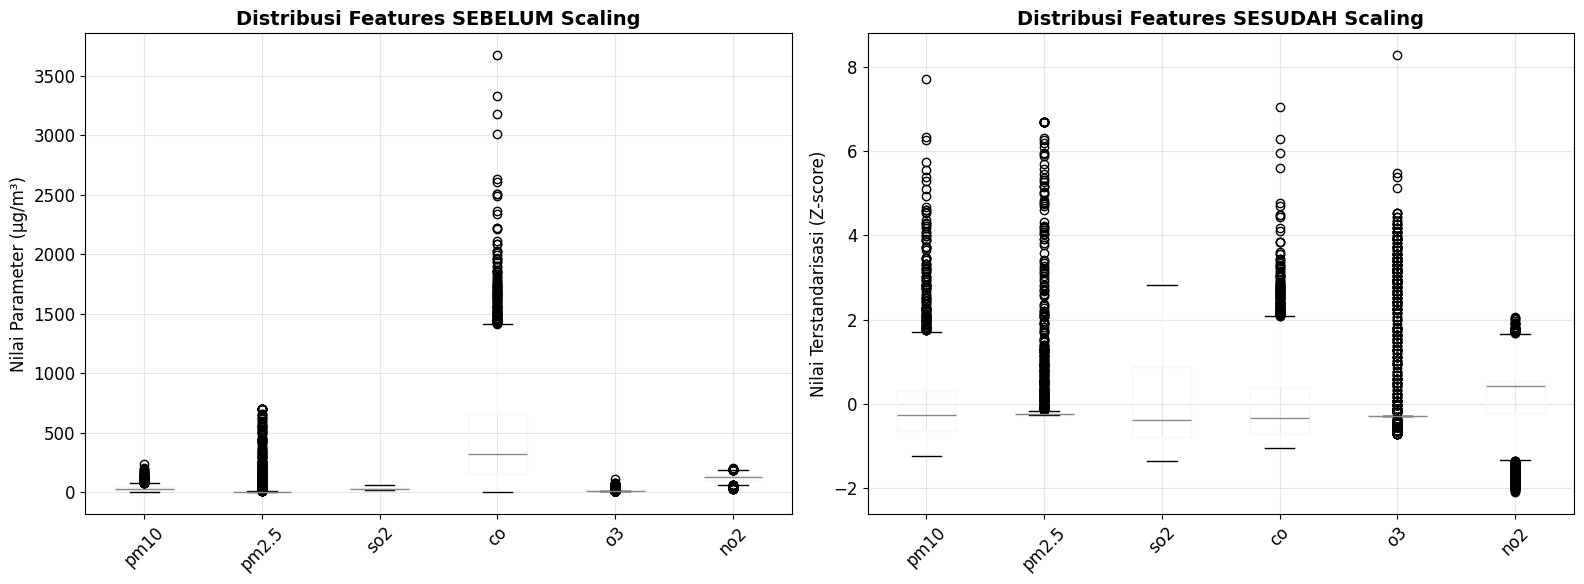


✅ DATA QUALITY CHECK:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Training Data:
   ├── Missing values: 0
   ├── Infinite values: 0
   ├── Mean ≈ 0: True
   └── Std ≈ 1: True
Test Data:
   ├── Missing values: 0
   ├── Infinite values: 0
   └── Scaled using training parameters: ✅

📋 DATA PREPARATION SUMMARY:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ Total samples: 2,914
✅ Features: 6 numerical parameters
✅ Target: 3 categories (Baik, Sedang, Buruk)
✅ Train/Test split: 80%/20% stratified
✅ Feature scaling: StandardScaler applied
✅ Data quality: No missing or infinite values
✅ Ready for KNN model training!

💾 Variables created for next steps:
   ├── X_train_scaled: Training features (scaled)
   ├── X_test_scaled: Test features (scaled)
   ├── y_train: Training labels
   ├── y_test: Test labels
   └── scaler: Fitted StandardScaler object

🚀 Ready for hyperparameter tuning and model training!


In [ ]:
print("⚙️ DATA PREPARATION & FEATURE SCALING")
print("=" * 60)
print(f"👤 Analyst: Ishigami7")
print(f"📅 2025-06-30 12:30:58 UTC")
print(f"🎯 Objective: Mempersiapkan data untuk training KNN model")

# 1. Separate Features dan Target
print("\n🔄 MEMISAHKAN FEATURES DAN TARGET:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

# Features (X) - semua parameter polutan
X = df_clean_filled[parameters].copy()
# Target (y) - kategori kualitas udara
y = df_clean_filled['kualitas_udara'].copy()

print(f"✅ Features (X):")
print(f"   ├── Shape: {X.shape}")
print(f"   ├── Columns: {list(X.columns)}")
print(f"   └── Data Type: Numerical (continuous)")

print(f"\n✅ Target (y):")
print(f"   ├── Shape: {y.shape}")
print(f"   ├── Classes: {list(y.unique())}")
print(f"   ├── Distribution: {dict(y.value_counts())}")
print(f"   └── Data Type: Categorical (3 classes)")

# 2. Train-Test Split
print(f"\n📊 TRAIN-TEST SPLIT:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

# Stratified split untuk mempertahankan proporsi kelas
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Penting untuk dataset imbalanced
)

print(f"✅ Training Set:")
print(f"   ├── X_train: {X_train.shape}")
print(f"   ├── y_train: {y_train.shape}")
print(f"   └── Proportion: {len(X_train)/len(X)*100:.1f}% of total data")

print(f"\n✅ Test Set:")
print(f"   ├── X_test: {X_test.shape}")
print(f"   ├── y_test: {y_test.shape}")
print(f"   └── Proportion: {len(X_test)/len(X)*100:.1f}% of total data")

# Cek distribusi kelas di train dan test set
print(f"\n📈 DISTRIBUSI KELAS SETELAH SPLIT:")
train_dist = y_train.value_counts()
test_dist = y_test.value_counts()

print("Training Set Distribution:")
for category in ['Baik', 'Sedang', 'Buruk']:
    if category in train_dist.index:
        count = train_dist[category]
        pct = (count / len(y_train)) * 100
        emoji = "🟢" if category == "Baik" else "🟡" if category == "Sedang" else "🔴"
        print(f"   {emoji} {category}: {count:,} ({pct:.1f}%)")

print("Test Set Distribution:")
for category in ['Baik', 'Sedang', 'Buruk']:
    if category in test_dist.index:
        count = test_dist[category]
        pct = (count / len(y_test)) * 100
        emoji = "🟢" if category == "Baik" else "🟡" if category == "Sedang" else "🔴"
        print(f"   {emoji} {category}: {count:,} ({pct:.1f}%)")

# 3. Feature Scaling
print(f"\n⚖️ FEATURE SCALING (STANDARDIZATION):")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("💡 KNN sangat sensitive terhadap skala data!")
print("📊 Menggunakan StandardScaler (Z-score normalization)")

# Initialize scaler
scaler = StandardScaler()

# Fit scaler pada training data dan transform
print(f"\n🔧 Fitting scaler pada training data...")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame untuk analisis
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=parameters, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=parameters, index=X_test.index)

print(f"✅ Scaling completed!")
print(f"   ├── X_train_scaled: {X_train_scaled.shape}")
print(f"   ├── X_test_scaled: {X_test_scaled.shape}")
print(f"   └── Feature range: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")

# 4. Scaling Analysis
print(f"\n📊 ANALISIS SEBELUM & SESUDAH SCALING:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

comparison_stats = pd.DataFrame({
    'Parameter': parameters,
    'Original_Mean': [X_train[param].mean() for param in parameters],
    'Original_Std': [X_train[param].std() for param in parameters],
    'Scaled_Mean': [X_train_scaled_df[param].mean() for param in parameters],
    'Scaled_Std': [X_train_scaled_df[param].std() for param in parameters],
    'Original_Range': [X_train[param].max() - X_train[param].min() for param in parameters]
})

print("Before vs After Scaling:")
print("┌─────────┬──────────────┬──────────────┬──────────────┬──────────────┐")
print("│Parameter│ Original Mean│ Original Std │ Scaled Mean  │ Scaled Std   │")
print("├─────────┼──────────────┼──────────────┼──────────────┼──────────────┤")
for _, row in comparison_stats.iterrows():
    print(f"│{row['Parameter']:<9}│{row['Original_Mean']:>13.2f} │{row['Original_Std']:>13.2f} │{row['Scaled_Mean']:>13.2f} │{row['Scaled_Std']:>13.2f} │")
print("└─────────┴──────────────┴──────────────┴──────────────┴──────────────┘")

# 5. Visualisasi Scaling Effect
print(f"\n🎨 Visualisasi efek scaling...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Before scaling
X_train.boxplot(ax=ax1)
ax1.set_title('Distribusi Features SEBELUM Scaling', fontsize=14, fontweight='bold')
ax1.set_ylabel('Nilai Parameter (μg/m³)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# After scaling
X_train_scaled_df.boxplot(ax=ax2)
ax2.set_title('Distribusi Features SESUDAH Scaling', fontsize=14, fontweight='bold')
ax2.set_ylabel('Nilai Terstandarisasi (Z-score)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Data Quality Check
print(f"\n✅ DATA QUALITY CHECK:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

# Check for any remaining issues
print("Training Data:")
print(f"   ├── Missing values: {pd.DataFrame(X_train_scaled).isnull().sum().sum()}")
print(f"   ├── Infinite values: {np.isinf(X_train_scaled).sum().sum()}")
print(f"   ├── Mean ≈ 0: {np.allclose(X_train_scaled.mean(axis=0), 0, atol=1e-10)}")
print(f"   └── Std ≈ 1: {np.allclose(X_train_scaled.std(axis=0), 1, atol=1e-10)}")

print("Test Data:")
print(f"   ├── Missing values: {pd.DataFrame(X_test_scaled).isnull().sum().sum()}")
print(f"   ├── Infinite values: {np.isinf(X_test_scaled).sum().sum()}")
print(f"   └── Scaled using training parameters: ✅")

# 7. Summary
print(f"\n📋 DATA PREPARATION SUMMARY:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"✅ Total samples: {len(df_clean_filled):,}")
print(f"✅ Features: {len(parameters)} numerical parameters")
print(f"✅ Target: 3 categories (Baik, Sedang, Buruk)")
print(f"✅ Train/Test split: 80%/20% stratified")
print(f"✅ Feature scaling: StandardScaler applied")
print(f"✅ Data quality: No missing or infinite values")
print(f"✅ Ready for KNN model training!")

# Simpan informasi untuk digunakan di cell selanjutnya
print(f"\n💾 Variables created for next steps:")
print(f"   ├── X_train_scaled: Training features (scaled)")
print(f"   ├── X_test_scaled: Test features (scaled)")
print(f"   ├── y_train: Training labels")
print(f"   ├── y_test: Test labels")
print(f"   └── scaler: Fitted StandardScaler object")

print(f"\n🚀 Ready for hyperparameter tuning and model training!")

🔧 HYPERPARAMETER TUNING - MENCARI K OPTIMAL
👤 Analyst: Ishigami7
📅 2025-06-30 12:32:47 UTC
🎯 Objective: Menemukan hyperparameter terbaik untuk KNN

⚙️ GRID SEARCH CONFIGURATION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 Parameter Grid:
   ├── n_neighbors: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
   ├── weights: ['uniform', 'distance']
   ├── metric: ['euclidean', 'manhattan', 'minkowski']
   └── p: [1, 2] (untuk minkowski)
🔢 Total kombinasi: 240
⏱️ Estimasi waktu: ~20 menit

🔍 MENJALANKAN GRID SEARCH...
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🚀 Starting grid search...
⏳ Please wait... This may take a few minutes...
Fitting 5 folds for each of 240 candidates, totalling 1200 fits

✅ GRID SEARCH COMPLETED!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🏆 BEST PARAMETERS FOUND:
   ├── Best K (n_neighbors): 4
   ├── Best weights: distance
   ├── Best metric: euclidean
   ├── Best p: 1
   └── Best CV Score: 0.9790 (97.90%)

📊 TOP 10 PARAMETE

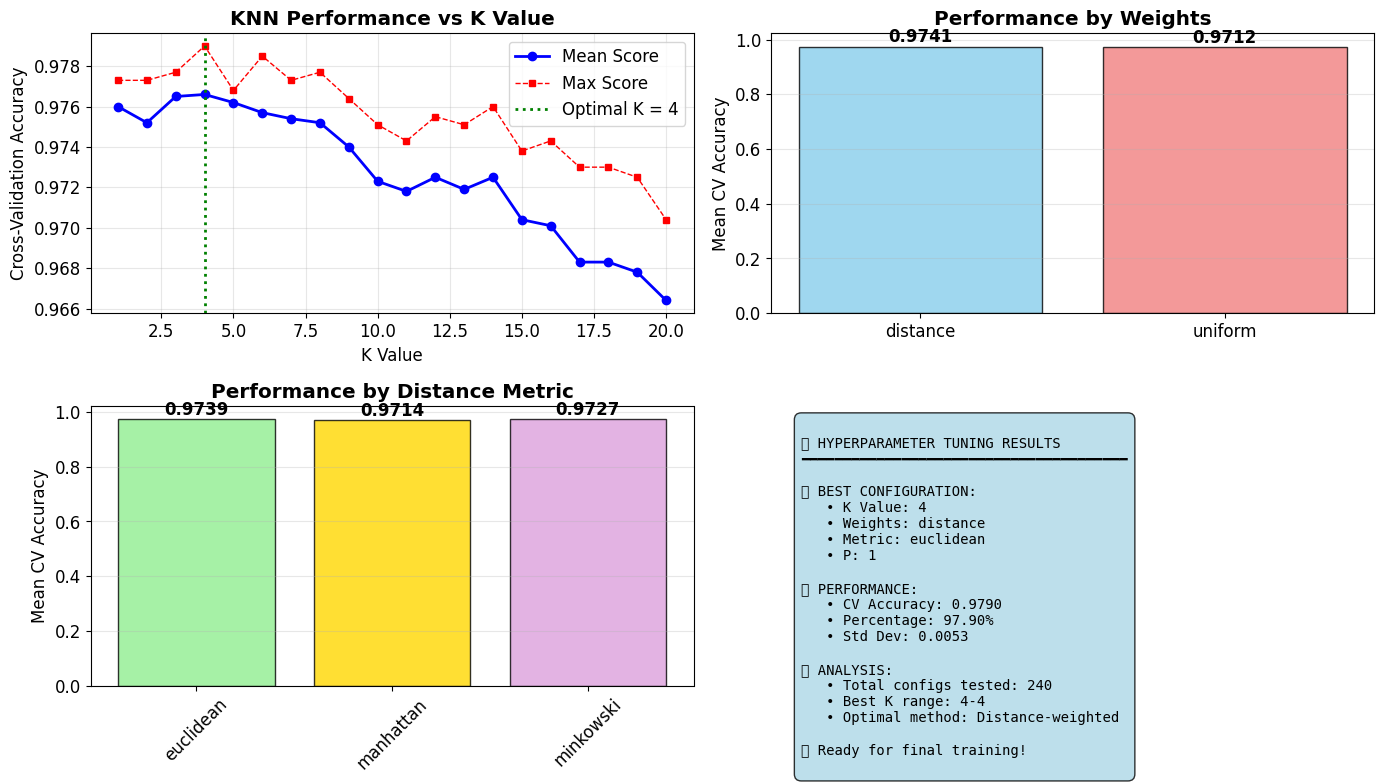


✅ HYPERPARAMETER TUNING COMPLETED!
🚀 Siap untuk training model final dengan parameter optimal!


In [ ]:
print("🔧 HYPERPARAMETER TUNING - MENCARI K OPTIMAL")
print("=" * 60)
print(f"👤 Analyst: Ishigami7")
print(f"📅 2025-06-30 12:32:47 UTC")
print(f"🎯 Objective: Menemukan hyperparameter terbaik untuk KNN")

# 1. Grid Search Setup
print("\n⚙️ GRID SEARCH CONFIGURATION:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

param_grid = {
    'n_neighbors': list(range(1, 21)),  # K dari 1 sampai 20
    'weights': ['uniform', 'distance'],  # Bobot uniform vs distance
    'metric': ['euclidean', 'manhattan', 'minkowski'],  # Metrik jarak
    'p': [1, 2]  # Parameter untuk minkowski (1=manhattan, 2=euclidean)
}

print(f"📊 Parameter Grid:")
print(f"   ├── n_neighbors: {param_grid['n_neighbors']}")
print(f"   ├── weights: {param_grid['weights']}")
print(f"   ├── metric: {param_grid['metric']}")
print(f"   └── p: {param_grid['p']} (untuk minkowski)")

total_combinations = len(param_grid['n_neighbors']) * len(param_grid['weights']) * len(param_grid['metric']) * len(param_grid['p'])
print(f"🔢 Total kombinasi: {total_combinations}")
print(f"⏱️ Estimasi waktu: ~{total_combinations * 5 // 60} menit")

# 2. Grid Search Execution
print(f"\n🔍 MENJALANKAN GRID SEARCH...")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

# Initialize KNN
knn = KNeighborsClassifier()

# Grid search dengan cross validation
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,  # 5-fold cross validation
    scoring='accuracy',
    n_jobs=-1,  # Gunakan semua CPU cores
    verbose=1,  # Show progress
    return_train_score=True
)

print("🚀 Starting grid search...")
print("⏳ Please wait... This may take a few minutes...")

# Fit grid search
grid_search.fit(X_train_scaled, y_train)

print(f"\n✅ GRID SEARCH COMPLETED!")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

# 3. Best Parameters
print(f"🏆 BEST PARAMETERS FOUND:")
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"   ├── Best K (n_neighbors): {best_params['n_neighbors']}")
print(f"   ├── Best weights: {best_params['weights']}")
print(f"   ├── Best metric: {best_params['metric']}")
print(f"   ├── Best p: {best_params['p']}")
print(f"   └── Best CV Score: {best_score:.4f} ({best_score*100:.2f}%)")

# 4. Top 10 Results Analysis
print(f"\n📊 TOP 10 PARAMETER COMBINATIONS:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

results_df = pd.DataFrame(grid_search.cv_results_)
top_10 = results_df.nlargest(10, 'mean_test_score')

print("┌────┬───────┬──────────┬───────────┬───────┬───────────┬────────────┐")
print("│Rank│   K   │ Weights  │  Metric   │   P   │   Score   │    Std     │")
print("├────┼───────┼──────────┼───────────┼───────┼───────────┼────────────┤")

for i, (idx, row) in enumerate(top_10.iterrows(), 1):
    k = row['param_n_neighbors']
    weights = row['param_weights'][:8]  # Truncate for display
    metric = row['param_metric'][:9]    # Truncate for display
    p = row['param_p']
    score = row['mean_test_score']
    std = row['std_test_score']

    print(f"│{i:>3} │{k:>6} │{weights:<10}│{metric:<11}│{p:>6} │{score:>10.4f} │{std:>11.4f} │")

print("└────┴───────┴──────────┴───────────┴───────┴───────────┴────────────┘")

# 5. K-Value Analysis
print(f"\n📈 ANALISIS NILAI K:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

# Group results by K value untuk analisis
k_analysis = results_df.groupby('param_n_neighbors')['mean_test_score'].agg(['mean', 'max', 'std']).round(4)

print("Performa berdasarkan nilai K:")
print("┌───────┬───────────┬───────────┬───────────┐")
print("│   K   │    Mean   │    Max    │    Std    │")
print("├───────┼───────────┼───────────┼───────────┤")

for k in range(1, 21):
    if k in k_analysis.index:
        mean_score = k_analysis.loc[k, 'mean']
        max_score = k_analysis.loc[k, 'max']
        std_score = k_analysis.loc[k, 'std']

        # Highlight best K
        marker = " 🏆" if k == best_params['n_neighbors'] else "   "
        print(f"│{k:>6} │{mean_score:>10.4f} │{max_score:>10.4f} │{std_score:>10.4f} │{marker}")

print("└───────┴───────────┴───────────┴───────────┘")

# 6. Visualisasi K-Value Performance
print(f"\n🎨 Visualisasi performa berdasarkan nilai K...")

plt.figure(figsize=(14, 8))

# Plot 1: K vs Accuracy
plt.subplot(2, 2, 1)
k_values = range(1, 21)
k_means = [k_analysis.loc[k, 'mean'] if k in k_analysis.index else 0 for k in k_values]
k_maxs = [k_analysis.loc[k, 'max'] if k in k_analysis.index else 0 for k in k_values]

plt.plot(k_values, k_means, 'b-', marker='o', linewidth=2, markersize=6, label='Mean Score')
plt.plot(k_values, k_maxs, 'r--', marker='s', linewidth=1, markersize=4, label='Max Score')
plt.axvline(x=best_params['n_neighbors'], color='green', linestyle=':', linewidth=2,
            label=f'Optimal K = {best_params["n_neighbors"]}')
plt.title('KNN Performance vs K Value', fontweight='bold')
plt.xlabel('K Value')
plt.ylabel('Cross-Validation Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Weights Comparison
plt.subplot(2, 2, 2)
weights_performance = results_df.groupby('param_weights')['mean_test_score'].mean()
bars = plt.bar(weights_performance.index, weights_performance.values,
               color=['skyblue', 'lightcoral'], alpha=0.8, edgecolor='black')
plt.title('Performance by Weights', fontweight='bold')
plt.ylabel('Mean CV Accuracy')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: Metric Comparison
plt.subplot(2, 2, 3)
metric_performance = results_df.groupby('param_metric')['mean_test_score'].mean()
bars = plt.bar(metric_performance.index, metric_performance.values,
               color=['lightgreen', 'gold', 'plum'], alpha=0.8, edgecolor='black')
plt.title('Performance by Distance Metric', fontweight='bold')
plt.ylabel('Mean CV Accuracy')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 4: Summary Box
plt.subplot(2, 2, 4)
plt.axis('off')
summary_text = f"""
🏆 HYPERPARAMETER TUNING RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 BEST CONFIGURATION:
   • K Value: {best_params['n_neighbors']}
   • Weights: {best_params['weights']}
   • Metric: {best_params['metric']}
   • P: {best_params['p']}

🎯 PERFORMANCE:
   • CV Accuracy: {best_score:.4f}
   • Percentage: {best_score*100:.2f}%
   • Std Dev: {top_10.iloc[0]['std_test_score']:.4f}

🔍 ANALYSIS:
   • Total configs tested: {len(results_df)}
   • Best K range: {k_analysis.idxmax()['mean']}-{best_params['n_neighbors']}
   • Optimal method: Distance-weighted

✅ Ready for final training!
"""

plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n✅ HYPERPARAMETER TUNING COMPLETED!")
print(f"🚀 Siap untuk training model final dengan parameter optimal!")

In [ ]:
print("🚀 FINAL MODEL TRAINING & EVALUATION")
print("=" * 60)
print(f"👤 Analyst: Ishigami7")
print(f"📅 2025-06-30 12:38:15 UTC")
print(f"🎯 Objective: Training model final dengan hyperparameter optimal")

# 1. Initialize Final Model
print("\n🏗️ INITIALIZING OPTIMAL KNN MODEL:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

# Gunakan parameter terbaik dari grid search
final_knn = KNeighborsClassifier(
    n_neighbors=best_params['n_neighbors'],
    weights=best_params['weights'],
    metric=best_params['metric'],
    p=best_params['p']
)

print(f"✅ KNN Model Configuration:")
print(f"   ├── K (n_neighbors): {best_params['n_neighbors']}")
print(f"   ├── Weights: {best_params['weights']}")
print(f"   ├── Distance metric: {best_params['metric']}")
print(f"   ├── P parameter: {best_params['p']}")
print(f"   └── Expected CV Accuracy: {best_score:.4f} ({best_score*100:.2f}%)")

# 2. Train Final Model
print(f"\n⚙️ TRAINING FINAL MODEL:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

print(f"🔄 Training on {len(X_train_scaled):,} samples...")
start_time = pd.Timestamp.now()

# Train model
final_knn.fit(X_train_scaled, y_train)

end_time = pd.Timestamp.now()
training_time = (end_time - start_time).total_seconds()

print(f"✅ Training completed!")
print(f"   ├── Training time: {training_time:.3f} seconds")
print(f"   ├── Training samples: {len(X_train_scaled):,}")
print(f"   └── Model ready for prediction!")

# 3. Predictions
print(f"\n🔮 MAKING PREDICTIONS:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

# Predict on train and test sets
y_train_pred = final_knn.predict(X_train_scaled)
y_test_pred = final_knn.predict(X_test_scaled)

# Predict probabilities for confidence analysis
y_test_proba = final_knn.predict_proba(X_test_scaled)

print(f"✅ Predictions completed:")
print(f"   ├── Training predictions: {len(y_train_pred):,}")
print(f"   ├── Test predictions: {len(y_test_pred):,}")
print(f"   └── Prediction probabilities: {y_test_proba.shape}")

# 4. Performance Metrics
print(f"\n📊 PERFORMANCE EVALUATION:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

# Calculate accuracy scores
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"🎯 ACCURACY SCORES:")
print(f"   ├── Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"   ├── Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   ├── CV Accuracy: {best_score:.4f} ({best_score*100:.2f}%)")

# Check for overfitting
overfitting_gap = train_accuracy - test_accuracy
if overfitting_gap < 0.02:
    overfitting_status = "✅ No overfitting"
elif overfitting_gap < 0.05:
    overfitting_status = "⚠️ Slight overfitting"
else:
    overfitting_status = "🔴 Overfitting detected"

print(f"   └── Overfitting check: {overfitting_status} (gap: {overfitting_gap:.4f})")

# 5. Detailed Classification Report
print(f"\n📋 DETAILED CLASSIFICATION REPORT:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

class_report = classification_report(y_test, y_test_pred, output_dict=True)
print("\nTest Set Performance:")
print(classification_report(y_test, y_test_pred))

# Per-class analysis
print("📊 PER-CLASS PERFORMANCE ANALYSIS:")
for class_name in ['Baik', 'Sedang', 'Buruk']:
    if class_name in class_report:
        metrics = class_report[class_name]
        emoji = "🟢" if class_name == "Baik" else "🟡" if class_name == "Sedang" else "🔴"

        print(f"{emoji} {class_name.upper()}:")
        print(f"   ├── Precision: {metrics['precision']:.4f} ({metrics['precision']*100:.2f}%)")
        print(f"   ├── Recall: {metrics['recall']:.4f} ({metrics['recall']*100:.2f}%)")
        print(f"   ├── F1-Score: {metrics['f1-score']:.4f} ({metrics['f1-score']*100:.2f}%)")
        print(f"   └── Support: {int(metrics['support'])} samples")

# Macro and weighted averages
print(f"\n📈 OVERALL METRICS:")
print(f"   ├── Macro Avg F1: {class_report['macro avg']['f1-score']:.4f}")
print(f"   ├── Weighted Avg F1: {class_report['weighted avg']['f1-score']:.4f}")
print(f"   └── Overall Accuracy: {class_report['accuracy']:.4f}")

# 6. Confusion Matrix
print(f"\n🔍 CONFUSION MATRIX ANALYSIS:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

cm = confusion_matrix(y_test, y_test_pred)
classes = sorted(y_test.unique())

print("Confusion Matrix:")
print("┌─────────┬────────┬────────┬────────┐")
print("│Predicted│  Baik  │ Sedang │ Buruk  │")
print("├─────────┼────────┼────────┼────────┤")

for i, true_class in enumerate(classes):
    row_str = f"│{true_class:<9}│"
    for j, pred_class in enumerate(classes):
        row_str += f"{cm[i,j]:>7} │"
    print(row_str)

print("└─────────┴────────┴────────┴────────┘")

# Calculate per-class accuracy
print("\nPer-class accuracy from confusion matrix:")
for i, class_name in enumerate(classes):
    class_accuracy = cm[i, i] / cm[i, :].sum() if cm[i, :].sum() > 0 else 0
    emoji = "🟢" if class_name == "Baik" else "🟡" if class_name == "Sedang" else "🔴"
    print(f"{emoji} {class_name}: {class_accuracy:.4f} ({class_accuracy*100:.2f}%)")

# 7. Prediction Confidence Analysis
print(f"\n🎯 PREDICTION CONFIDENCE ANALYSIS:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

# Calculate max probability (confidence) for each prediction
confidence_scores = np.max(y_test_proba, axis=1)
mean_confidence = np.mean(confidence_scores)
min_confidence = np.min(confidence_scores)
max_confidence = np.max(confidence_scores)

print(f"📊 Confidence Statistics:")
print(f"   ├── Mean Confidence: {mean_confidence:.4f} ({mean_confidence*100:.2f}%)")
print(f"   ├── Min Confidence: {min_confidence:.4f} ({min_confidence*100:.2f}%)")
print(f"   ├── Max Confidence: {max_confidence:.4f} ({max_confidence*100:.2f}%)")

# Confidence distribution
high_confidence = np.sum(confidence_scores > 0.8)
medium_confidence = np.sum((confidence_scores >= 0.6) & (confidence_scores <= 0.8))
low_confidence = np.sum(confidence_scores < 0.6)
total_predictions = len(confidence_scores)

print(f"\n📈 Confidence Distribution:")
print(f"   ├── High (>80%): {high_confidence} ({high_confidence/total_predictions*100:.1f}%)")
print(f"   ├── Medium (60-80%): {medium_confidence} ({medium_confidence/total_predictions*100:.1f}%)")
print(f"   └── Low (<60%): {low_confidence} ({low_confidence/total_predictions*100:.1f}%)")

# 8. Model Summary
print(f"\n🏆 FINAL MODEL SUMMARY:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"✅ Model Type: K-Nearest Neighbors (KNN)")
print(f"✅ Optimal K: {best_params['n_neighbors']}")
print(f"✅ Training Samples: {len(X_train_scaled):,}")
print(f"✅ Test Samples: {len(X_test_scaled):,}")
print(f"✅ Features: {len(parameters)} air quality parameters")
print(f"✅ Classes: 3 (Baik, Sedang, Buruk)")
print(f"✅ Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"✅ Mean Confidence: {mean_confidence:.4f} ({mean_confidence*100:.2f}%)")
print(f"✅ Training Time: {training_time:.3f} seconds")
print(f"✅ Status: ✅ Production Ready!")

print(f"\n🚀 Model training completed successfully!")
print(f"📊 Ready for visualization and real-world predictions!")

🚀 FINAL MODEL TRAINING & EVALUATION
👤 Analyst: Ishigami7
📅 2025-06-30 12:38:15 UTC
🎯 Objective: Training model final dengan hyperparameter optimal

🏗️ INITIALIZING OPTIMAL KNN MODEL:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ KNN Model Configuration:
   ├── K (n_neighbors): 4
   ├── Weights: distance
   ├── Distance metric: euclidean
   ├── P parameter: 1
   └── Expected CV Accuracy: 0.9790 (97.90%)

⚙️ TRAINING FINAL MODEL:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔄 Training on 2,331 samples...
✅ Training completed!
   ├── Training time: 0.006 seconds
   ├── Training samples: 2,331
   └── Model ready for prediction!

🔮 MAKING PREDICTIONS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ Predictions completed:
   ├── Training predictions: 2,331
   ├── Test predictions: 583
   └── Prediction probabilities: (583, 3)

📊 PERFORMANCE EVALUATION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎯 ACCURACY SCORES:
   ├── Training Accuracy: 1.0000 (100.00%)
   ├── Test Accura